# LOB Analysis
Exploratory analysis of limit order book and trade data.
Switch `DATA_DIR` and `PAIR` in the config cell to analyse any exchange/pair.

In [39]:
# ── Config ──────────────────────────────────────────────────────────────────
from pathlib import Path

DATA_DIR = Path("../data/nobitex_data")  # swap for another exchange dir
PAIR = "BTCIRT"  # filename prefix inside DATA_DIR
N_LEVELS = 10  # how many LOB levels to use

OB_FILE = DATA_DIR / f"{PAIR}_orderbook.csv"
TRADE_FILE = DATA_DIR / f"{PAIR}_trades.csv"
print(f"orderbook : {OB_FILE}")
print(f"trades    : {TRADE_FILE}")

orderbook : ../data/nobitex_data/BTCIRT_orderbook.csv
trades    : ../data/nobitex_data/BTCIRT_trades.csv


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

## 1  Load data

In [41]:
ob = pd.read_csv(OB_FILE, parse_dates=["time"])
ob = ob.sort_values("time").reset_index(drop=True)

trades = pd.read_csv(TRADE_FILE, parse_dates=["snapshot_time", "trade_time"])
trades = trades.sort_values("trade_time").reset_index(drop=True)

print("orderbook  rows:", len(ob), " | range:", ob["time"].min(), "→", ob["time"].max())
print(
    "trades     rows:",
    len(trades),
    " | range:",
    trades["trade_time"].min(),
    "→",
    trades["trade_time"].max(),
)

orderbook  rows: 83131  | range: 2026-06-08 13:06:14 → 2026-06-18 08:19:14
trades     rows: 52571  | range: 2026-06-08 13:01:07.108000 → 2026-06-18 08:03:22.072000


In [42]:
# Separate bid / ask columns for the first N_LEVELS levels
bid_price_cols = [f"bid_price_{i}" for i in range(1, N_LEVELS + 1)]
bid_volume_cols = [f"bid_volume_{i}" for i in range(1, N_LEVELS + 1)]
ask_price_cols = [f"ask_price_{i}" for i in range(1, N_LEVELS + 1)]
ask_volume_cols = [f"ask_volume_{i}" for i in range(1, N_LEVELS + 1)]

ob.head(2)

,time,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,bid_price_2,bid_volume_2,ask_price_2,ask_volume_2,bid_price_3,...,ask_price_18,ask_volume_18,bid_price_19,bid_volume_19,ask_price_19,ask_volume_19,bid_price_20,bid_volume_20,ask_price_20,ask_volume_20
0,2026-06-08 13:06:14,112825000000,0.013633,112700000000,0.016998,112829989940,0.000727,112686856600,0.000044,112829989950,...,111080990000,0.0001,113000000000,0.011774,111016872360,0.000012,113000008000,0.0002,111000000010,0.009882
1,2026-06-08 13:06:24,112825000000,0.013552,112700000000,0.016077,112829989940,0.000727,112686856600,0.000044,112829989950,...,111080990000,0.0001,113000000000,0.011774,111016872360,0.000012,113000008000,0.0002,111000000010,0.009882


In [43]:
trades.head(2)

,snapshot_time,trade_time,price,volume,direction
0,2026-06-08 13:06:14,2026-06-08 13:01:07.108,112825000000,0.000425,buy
1,2026-06-08 13:06:14,2026-06-08 13:01:24.994,112700000000,0.001683,sell


## 2  Derived series

In [44]:
ob["mid_price"] = (ob["bid_price_1"] + ob["ask_price_1"]) / 2
ob["spread"] = ob["ask_price_1"] - ob["bid_price_1"]
ob["spread_bps"] = ob["spread"] / ob["mid_price"] * 1e4

# Total depth at each level
ob["total_bid_vol"] = ob[bid_volume_cols].sum(axis=1)
ob["total_ask_vol"] = ob[ask_volume_cols].sum(axis=1)

# Order-book imbalance (OBI) using best-level volumes
ob["obi"] = (ob["bid_volume_1"] - ob["ask_volume_1"]) / (
    ob["bid_volume_1"] + ob["ask_volume_1"]
).replace(0, np.nan)

ob[
    [
        "time",
        "mid_price",
        "spread",
        "spread_bps",
        "total_bid_vol",
        "total_ask_vol",
        "obi",
    ]
].describe()

,time,mid_price,spread,spread_bps,total_bid_vol,total_ask_vol,obi
count,83131,8.313100e+04,8.313100e+04,8.313100e+04,83131.000000,83131.000000,83131.000000
mean,2026-06-13 10:25:18.487122432,1.083799e+11,-1.869108e+08,-1.727961e+01,0.047378,0.046885,0.030441
min,2026-06-08 13:06:14,9.780001e+10,-1.258285e+09,-1.152918e+02,0.000673,0.000192,-0.999929
25%,2026-06-10 23:29:29,1.061716e+11,-2.850913e+08,-2.638624e+01,0.024125,0.028610,-0.667266
50%,2026-06-13 09:21:04,1.094403e+11,-1.811070e+08,-1.674796e+01,0.038364,0.040284,0.010769
75%,2026-06-15 21:50:19,1.111403e+11,-6.165113e+07,-5.727404e+00,0.059842,0.058108,0.747748
max,2026-06-18 08:19:14,1.140000e+11,-1.000000e+01,-8.771930e-07,0.379457,0.450078,0.999921
std,NaN,3.841074e+09,1.414376e+08,1.308461e+01,0.034261,0.028832,0.702862


## 3  Mid-price & spread over time

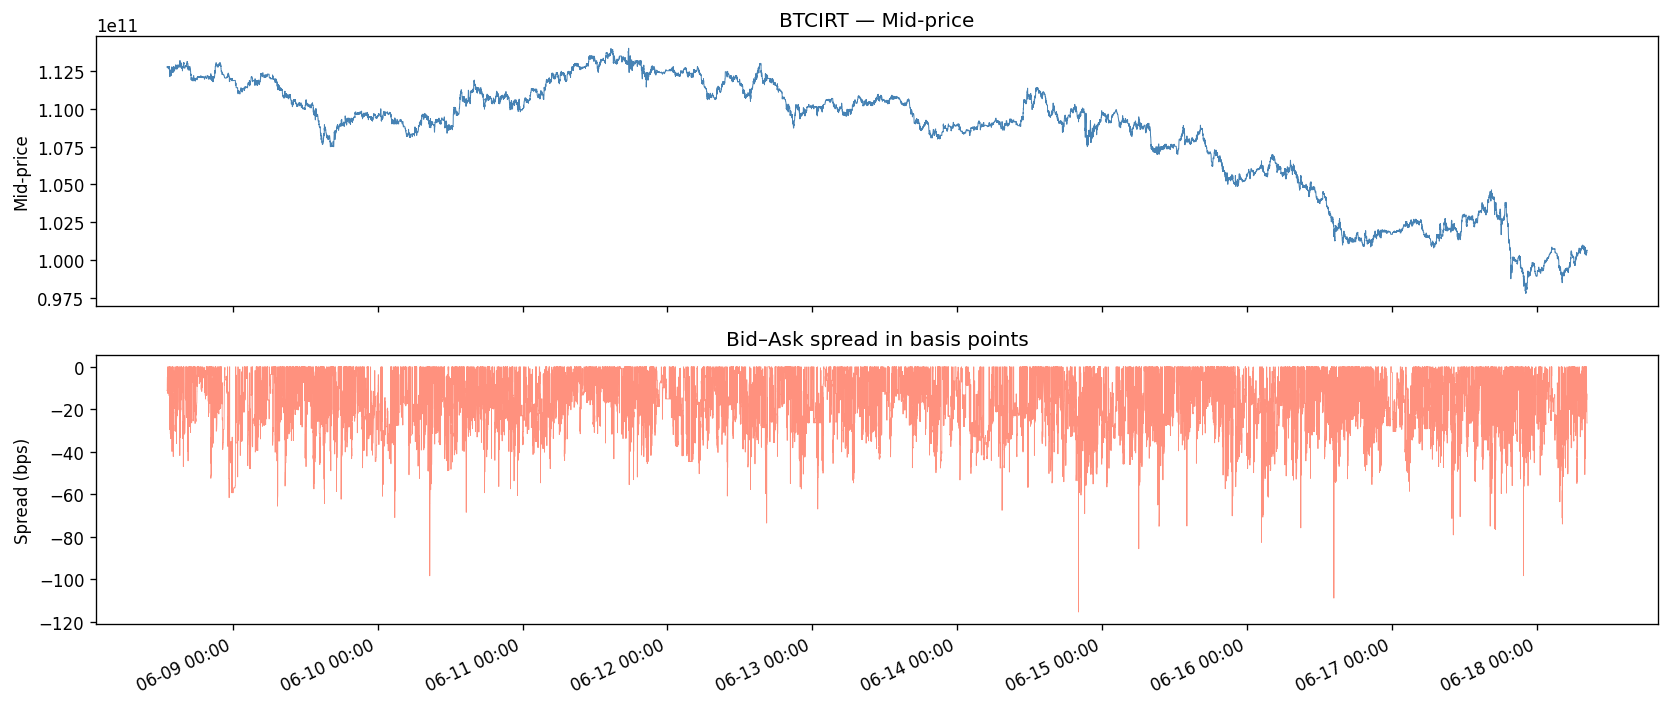

In [45]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 6))

axes[0].plot(ob["time"], ob["mid_price"], lw=0.6, color="steelblue")
axes[0].set_ylabel("Mid-price")
axes[0].set_title(f"{PAIR} — Mid-price")

axes[1].plot(ob["time"], ob["spread_bps"], lw=0.5, color="tomato", alpha=0.7)
axes[1].set_ylabel("Spread (bps)")
axes[1].set_title("Bid–Ask spread in basis points")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 4  Average LOB depth profile

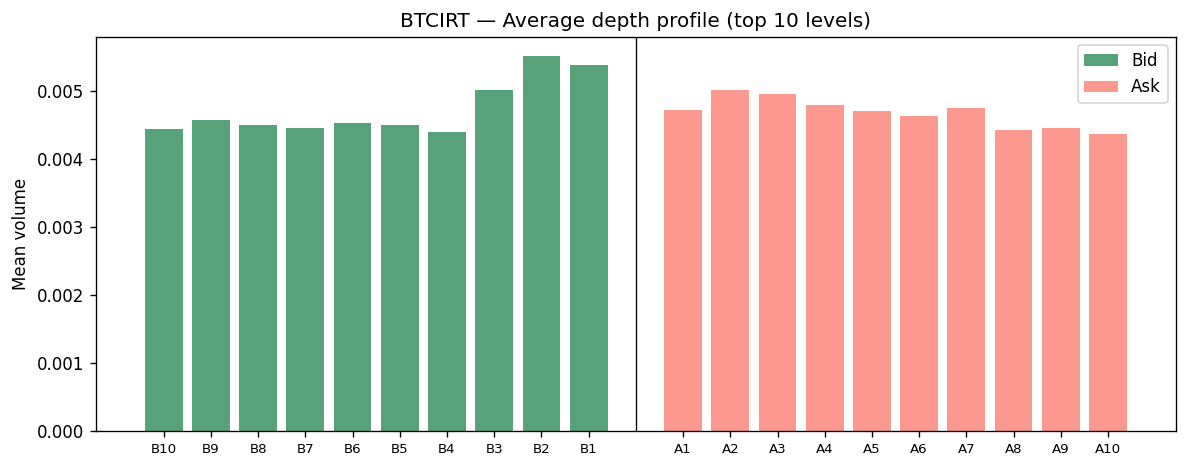

In [46]:
# Mean volume at each level (relative to best bid/ask price)
mean_bid_vol = ob[bid_volume_cols].mean()
mean_ask_vol = ob[ask_volume_cols].mean()

levels = range(1, N_LEVELS + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    [-lv for lv in levels],
    mean_bid_vol.values,
    color="seagreen",
    alpha=0.8,
    label="Bid",
)
ax.bar(
    [+lv for lv in levels], mean_ask_vol.values, color="salmon", alpha=0.8, label="Ask"
)
ax.axvline(0, color="k", lw=0.8)
ax.set_xticks(list(-lv for lv in levels) + list(lv for lv in levels))
ax.set_xticklabels(
    [f"B{lv}" for lv in levels] + [f"A{lv}" for lv in levels], fontsize=8
)
ax.set_ylabel("Mean volume")
ax.set_title(f"{PAIR} — Average depth profile (top {N_LEVELS} levels)")
ax.legend()
plt.tight_layout()
plt.show()

## 5  Cumulative depth over time

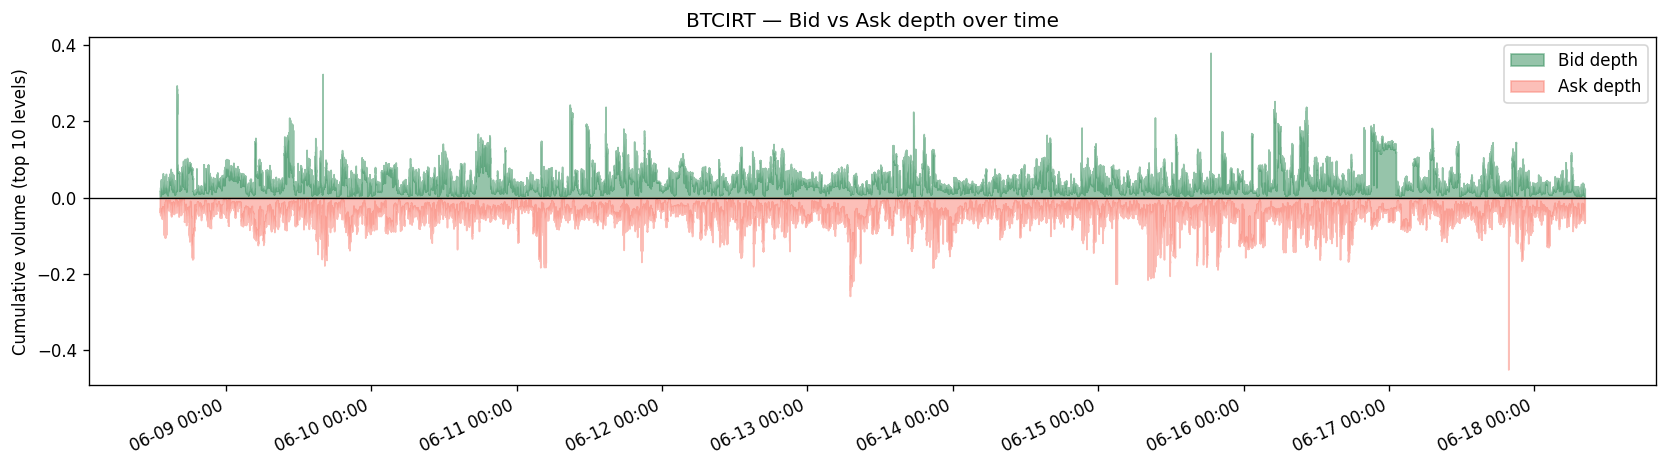

In [47]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(
    ob["time"], ob["total_bid_vol"], alpha=0.5, color="seagreen", label="Bid depth"
)
ax.fill_between(
    ob["time"], -ob["total_ask_vol"], alpha=0.5, color="salmon", label="Ask depth"
)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel(f"Cumulative volume (top {N_LEVELS} levels)")
ax.set_title(f"{PAIR} — Bid vs Ask depth over time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 6  Order-book imbalance (OBI)

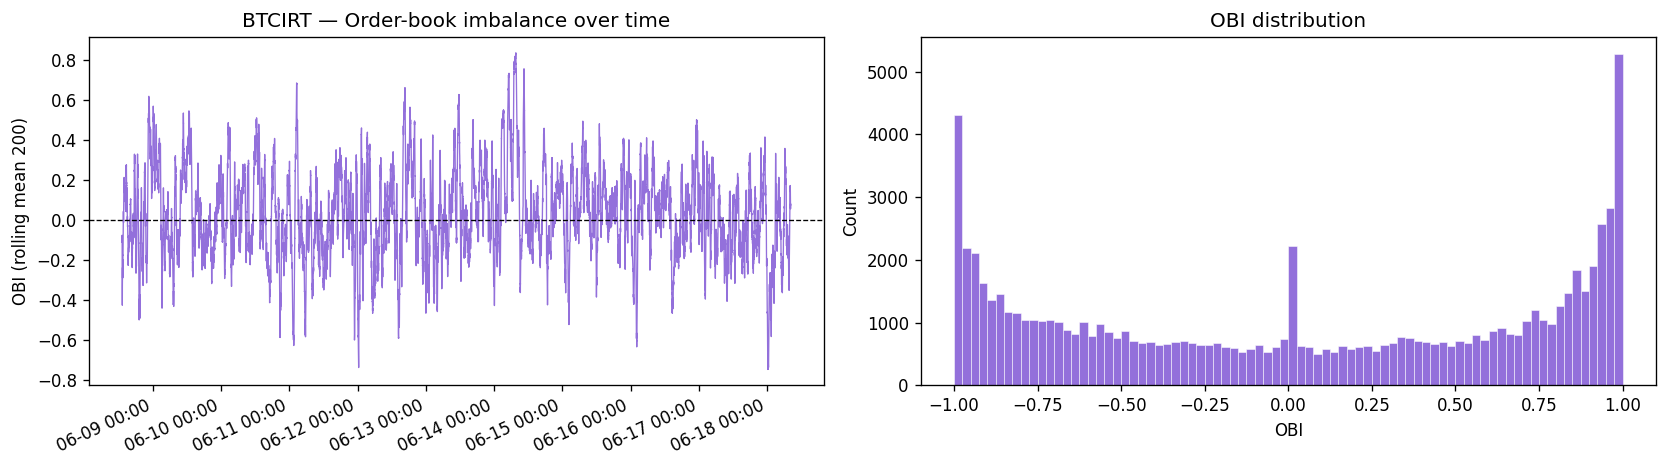

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
axes[0].plot(
    ob["time"],
    ob["obi"].rolling(200, min_periods=1).mean(),
    lw=0.8,
    color="mediumpurple",
)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_ylabel("OBI (rolling mean 200)")
axes[0].set_title(f"{PAIR} — Order-book imbalance over time")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")

# Distribution
axes[1].hist(
    ob["obi"].dropna(), bins=80, color="mediumpurple", edgecolor="white", lw=0.3
)
axes[1].set_xlabel("OBI")
axes[1].set_ylabel("Count")
axes[1].set_title("OBI distribution")

plt.tight_layout()
plt.show()

## 7  LOB heatmap (price × time)

In [49]:
# Downsample to at most 2000 snapshots for plotting performance
HMAP_ROWS = 2000
step = max(1, len(ob) // HMAP_ROWS)
ob_s = ob.iloc[::step].copy()

# Build a 2-D grid: rows = time snapshots, cols = price bins
all_bid_prices = ob_s[bid_price_cols].values
all_ask_prices = ob_s[ask_price_cols].values
all_bid_vols = ob_s[bid_volume_cols].values
all_ask_vols = ob_s[ask_volume_cols].values

p_min = np.nanpercentile(all_bid_prices, 1)
p_max = np.nanpercentile(all_ask_prices, 99)
N_BINS = 200
price_bins = np.linspace(p_min, p_max, N_BINS + 1)

hmap = np.zeros((len(ob_s), N_BINS))

for row_idx in range(len(ob_s)):
    for lvl in range(N_LEVELS):
        for prices, vols in [
            (all_bid_prices[:, lvl], all_bid_vols[:, lvl]),
            (all_ask_prices[:, lvl], all_ask_vols[:, lvl]),
        ]:
            p = prices[row_idx]
            v = vols[row_idx]
            if np.isnan(p) or p < p_min or p > p_max:
                continue
            bin_idx = np.searchsorted(price_bins, p, side="right") - 1
            bin_idx = np.clip(bin_idx, 0, N_BINS - 1)
            hmap[row_idx, bin_idx] += v

print(f"Heatmap shape: {hmap.shape}")

Heatmap shape: (2028, 200)


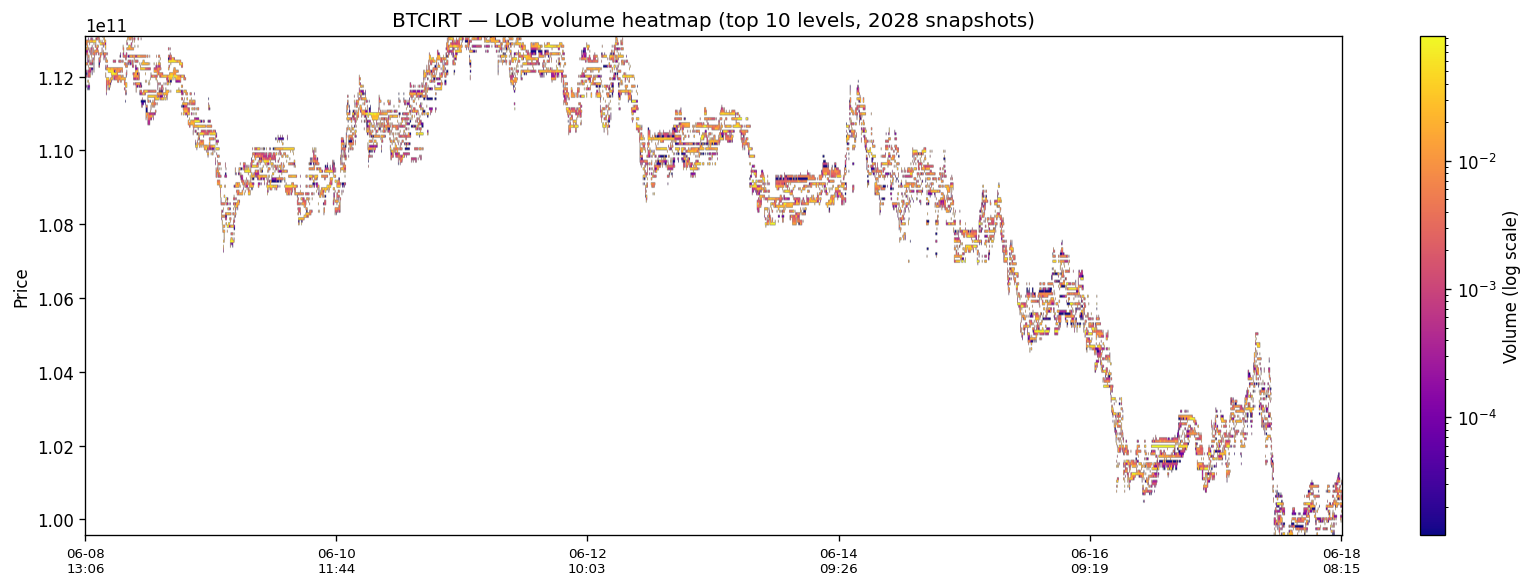

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))

hmap_nonzero = np.where(hmap > 0, hmap, np.nan)
im = ax.imshow(
    hmap_nonzero.T,
    aspect="auto",
    origin="lower",
    norm=LogNorm(
        vmin=np.nanpercentile(hmap_nonzero, 5), vmax=np.nanpercentile(hmap_nonzero, 99)
    ),
    cmap="plasma",
    extent=[0, len(ob_s), p_min, p_max],
)
plt.colorbar(im, ax=ax, label="Volume (log scale)")

# x-axis: convert row indices back to timestamps
n_ticks = 6
tick_idx = np.linspace(0, len(ob_s) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(
    [ob_s["time"].iloc[i].strftime("%m-%d\n%H:%M") for i in tick_idx], fontsize=8
)
ax.set_ylabel("Price")
ax.set_title(
    f"{PAIR} — LOB volume heatmap (top {N_LEVELS} levels, {len(ob_s)} snapshots)"
)
plt.tight_layout()
plt.show()

## 8  Trade analysis

In [51]:
trades["direction"].value_counts()

direction
sell    32469
buy     20102
Name: count, dtype: int64

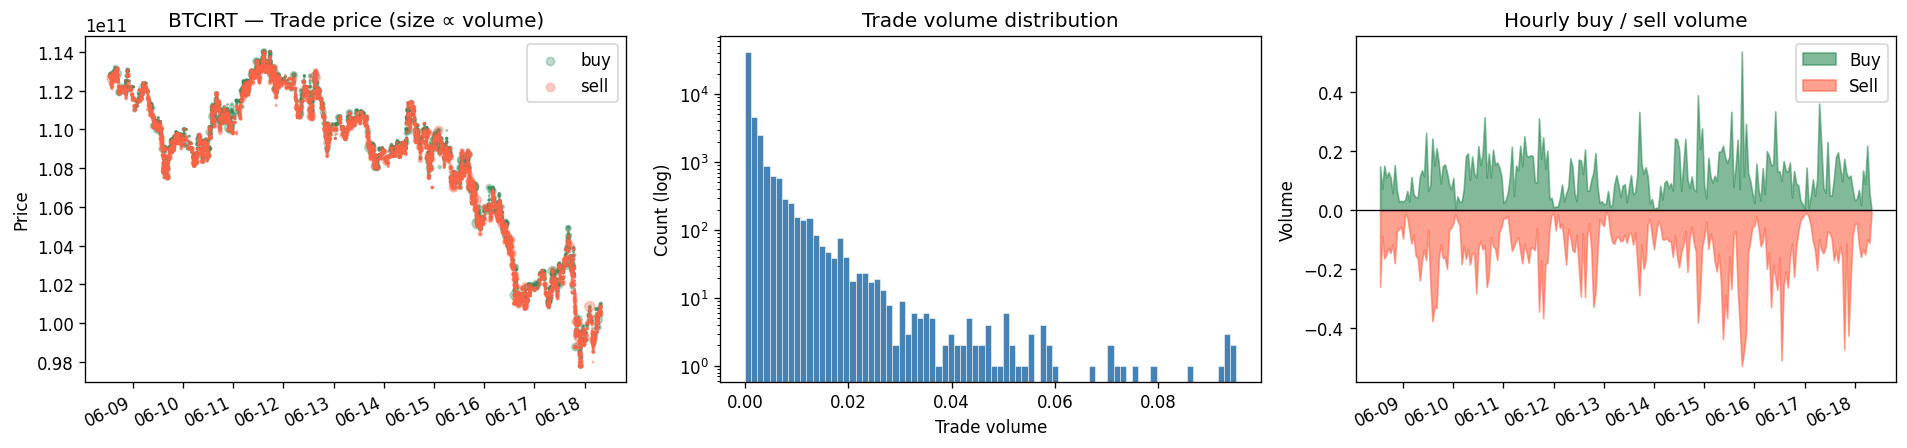

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trade price vs time
for direction, color in [("buy", "seagreen"), ("sell", "tomato")]:
    mask = trades["direction"] == direction
    axes[0].scatter(
        trades.loc[mask, "trade_time"],
        trades.loc[mask, "price"],
        s=trades.loc[mask, "volume"] * 500,
        alpha=0.3,
        color=color,
        label=direction,
    )
axes[0].set_title(f"{PAIR} — Trade price (size ∝ volume)")
axes[0].set_ylabel("Price")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")
axes[0].legend()

# Volume distribution
axes[1].hist(
    trades["volume"], bins=80, color="steelblue", edgecolor="white", lw=0.3, log=True
)
axes[1].set_xlabel("Trade volume")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Trade volume distribution")

# Buy / sell volume per hour
trades["hour"] = trades["trade_time"].dt.floor("h")
hourly = trades.groupby(["hour", "direction"])["volume"].sum().unstack(fill_value=0)
if "buy" in hourly.columns:
    axes[2].fill_between(
        hourly.index, hourly["buy"], alpha=0.6, color="seagreen", label="Buy"
    )
if "sell" in hourly.columns:
    axes[2].fill_between(
        hourly.index, -hourly["sell"], alpha=0.6, color="tomato", label="Sell"
    )
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_title("Hourly buy / sell volume")
axes[2].set_ylabel("Volume")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=25, ha="right")
axes[2].legend()

plt.tight_layout()
plt.show()

## 9  Trade flow vs mid-price

/Users/arshia/Projects/Personal/Penny/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


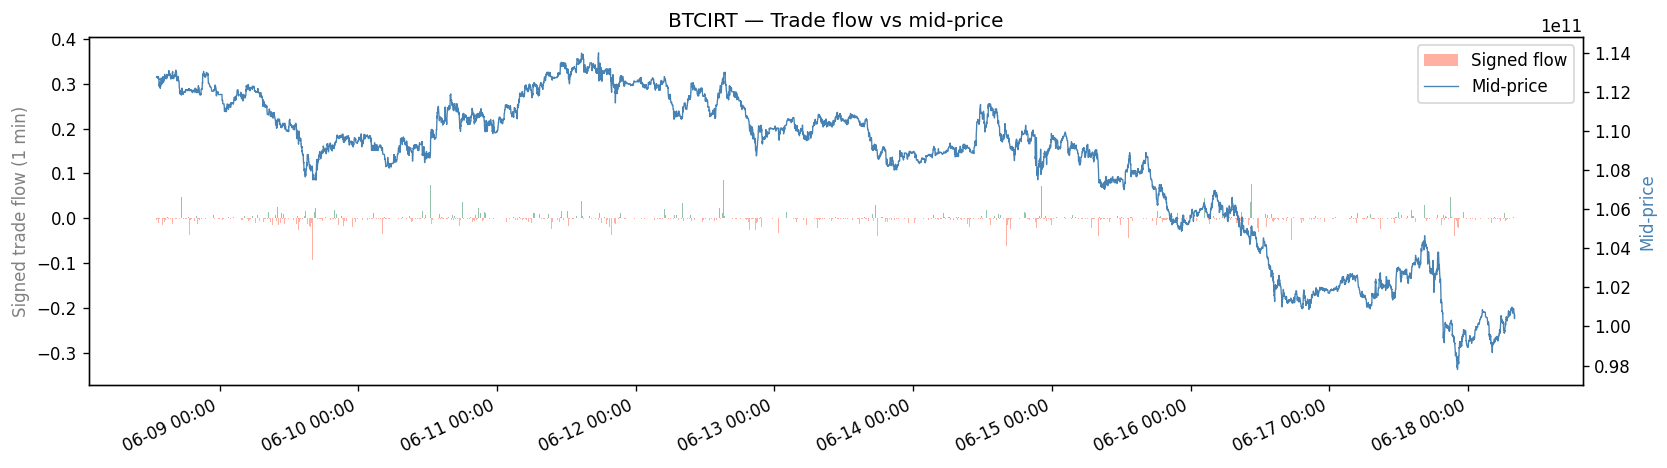

In [53]:
# Signed trade flow: buy = +volume, sell = -volume
trades["signed_volume"] = trades["volume"] * trades["direction"].map(
    {"buy": 1, "sell": -1}
)

# Resample to same frequency as OB snapshots (1-min buckets)
flow_1m = (
    trades.set_index("trade_time")["signed_volume"].resample("1min").sum().fillna(0)
)
mid_1m = ob.set_index("time")["mid_price"].resample("1min").last().ffill()

combined = pd.concat([flow_1m, mid_1m], axis=1, join="inner")
combined.columns = ["signed_flow", "mid_price"]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(
    combined.index,
    combined["signed_flow"],
    color=np.where(combined["signed_flow"] >= 0, "seagreen", "tomato"),
    alpha=0.5,
    width=0.0006,
    label="Signed flow",
)
ax2.plot(
    combined.index, combined["mid_price"], color="steelblue", lw=0.8, label="Mid-price"
)

ax1.set_ylabel("Signed trade flow (1 min)", color="grey")
ax2.set_ylabel("Mid-price", color="steelblue")
ax1.set_title(f"{PAIR} — Trade flow vs mid-price")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()

## 10  DeepLOB label calibration

For DeepLOB-style labels at horizon `k`, we use

$$
m_{-}(t, k) = \frac{1}{k} \sum_{i=0}^{k-1} m_{t-i}, \qquad
m_{+}(t, k) = \frac{1}{k} \sum_{i=1}^{k} m_{t+i}
$$

$$
r_t^{(k)} = \frac{m_{+}(t, k) - m_{-}(t, k)}{m_{-}(t, k)}
$$

and the label is

$$
y_t^{(k, \alpha)} = \begin{cases}
-1 & r_t^{(k)} < -\alpha \\
0 & |r_t^{(k)}| \le \alpha \\
+1 & r_t^{(k)} > \alpha
\end{cases}
$$

The cells below scan `\alpha` for each horizon and pick the value whose class mix is closest to a balanced 1/3-1/3-1/3 split. Horizons are measured in order-book snapshots, so adjust `HORIZONS` to match your sampling frequency.


In [54]:
def past_window_mean(values, window):
    values = np.asarray(values, dtype=float)
    out = np.full(len(values), np.nan, dtype=float)
    if window <= 0 or len(values) < window:
        return out
    csum = np.cumsum(np.insert(values, 0, 0.0))
    out[window - 1 :] = (csum[window:] - csum[:-window]) / window
    return out


def future_window_mean(values, window):
    values = np.asarray(values, dtype=float)
    out = np.full(len(values), np.nan, dtype=float)
    if window <= 0 or len(values) <= window:
        return out
    csum = np.cumsum(np.insert(values, 0, 0.0))
    out[: len(values) - window] = (csum[window + 1 :] - csum[1:-window]) / window
    return out


def deeplob_return(mid_price, horizon):
    past_mean = past_window_mean(mid_price, horizon)
    future_mean = future_window_mean(mid_price, horizon)
    returns = (future_mean - past_mean) / past_mean
    returns[~np.isfinite(returns)] = np.nan
    return returns


def make_deeplob_labels(mid_price, horizon, alpha):
    returns = deeplob_return(mid_price, horizon)
    labels = np.full(len(returns), np.nan, dtype=float)
    labels[returns < -alpha] = -1
    labels[np.abs(returns) <= alpha] = 0
    labels[returns > alpha] = 1
    return returns, labels


def scan_alpha_grid(returns, target_share=None, quantiles=None):
    target_share = (
        np.array([1 / 3, 1 / 3, 1 / 3])
        if target_share is None
        else np.asarray(target_share, dtype=float)
    )
    quantiles = (
        np.linspace(0.05, 0.95, 181)
        if quantiles is None
        else np.asarray(quantiles, dtype=float)
    )

    valid = returns[np.isfinite(returns)]
    if len(valid) == 0:
        raise ValueError("No valid DeepLOB returns for this horizon.")

    abs_valid = np.abs(valid)
    alpha_grid = np.unique(np.concatenate(([0.0], np.quantile(abs_valid, quantiles))))

    rows = []
    for alpha in alpha_grid:
        down_share = (valid < -alpha).mean()
        neutral_share = (np.abs(valid) <= alpha).mean()
        up_share = (valid > alpha).mean()
        shares = np.array([down_share, neutral_share, up_share])
        rows.append(
            {
                "alpha": alpha,
                "alpha_bps": alpha * 1e4,
                "down_share": down_share,
                "neutral_share": neutral_share,
                "up_share": up_share,
                "up_down_gap": abs(up_share - down_share),
                "balance_score": float(((shares - target_share) ** 2).sum()),
                "valid_samples": int(len(valid)),
            }
        )

    grid = pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)
    best = grid.sort_values(["balance_score", "up_down_gap", "alpha"]).iloc[0]
    return best, grid

In [55]:
HORIZONS = [10, 20, 50, 100]  # measured in order-book snapshots
TARGET_CLASS_SHARE = np.array([1 / 3, 1 / 3, 1 / 3])
ALPHA_QUANTILES = np.linspace(0.05, 0.95, 181)

mid = ob["mid_price"].to_numpy(dtype=float)

alpha_grids = {}
best_alpha_rows = []

for horizon in HORIZONS:
    returns = deeplob_return(mid, horizon)
    best_row, grid = scan_alpha_grid(
        returns,
        target_share=TARGET_CLASS_SHARE,
        quantiles=ALPHA_QUANTILES,
    )
    alpha_grids[horizon] = grid
    best_alpha_rows.append(
        {
            "horizon": horizon,
            "alpha": float(best_row["alpha"]),
            "alpha_bps": float(best_row["alpha_bps"]),
            "down_share": float(best_row["down_share"]),
            "neutral_share": float(best_row["neutral_share"]),
            "up_share": float(best_row["up_share"]),
            "up_down_gap": float(best_row["up_down_gap"]),
            "balance_score": float(best_row["balance_score"]),
            "valid_samples": int(best_row["valid_samples"]),
        }
    )

best_alpha_summary = (
    pd.DataFrame(best_alpha_rows).sort_values("horizon").reset_index(drop=True)
)
best_alpha_summary

,horizon,alpha,alpha_bps,down_share,neutral_share,up_share,up_down_gap,balance_score,valid_samples
0,10,0.000129,1.289409,0.344884,0.335006,0.320110,0.024774,0.000311,83112
1,20,0.000250,2.495989,0.344582,0.335002,0.320416,0.024166,0.000296,83092
2,50,0.000481,4.808361,0.352635,0.335003,0.312361,0.040274,0.000815,83032
3,100,0.000764,7.644012,0.354290,0.334997,0.310712,0.043578,0.000954,82932


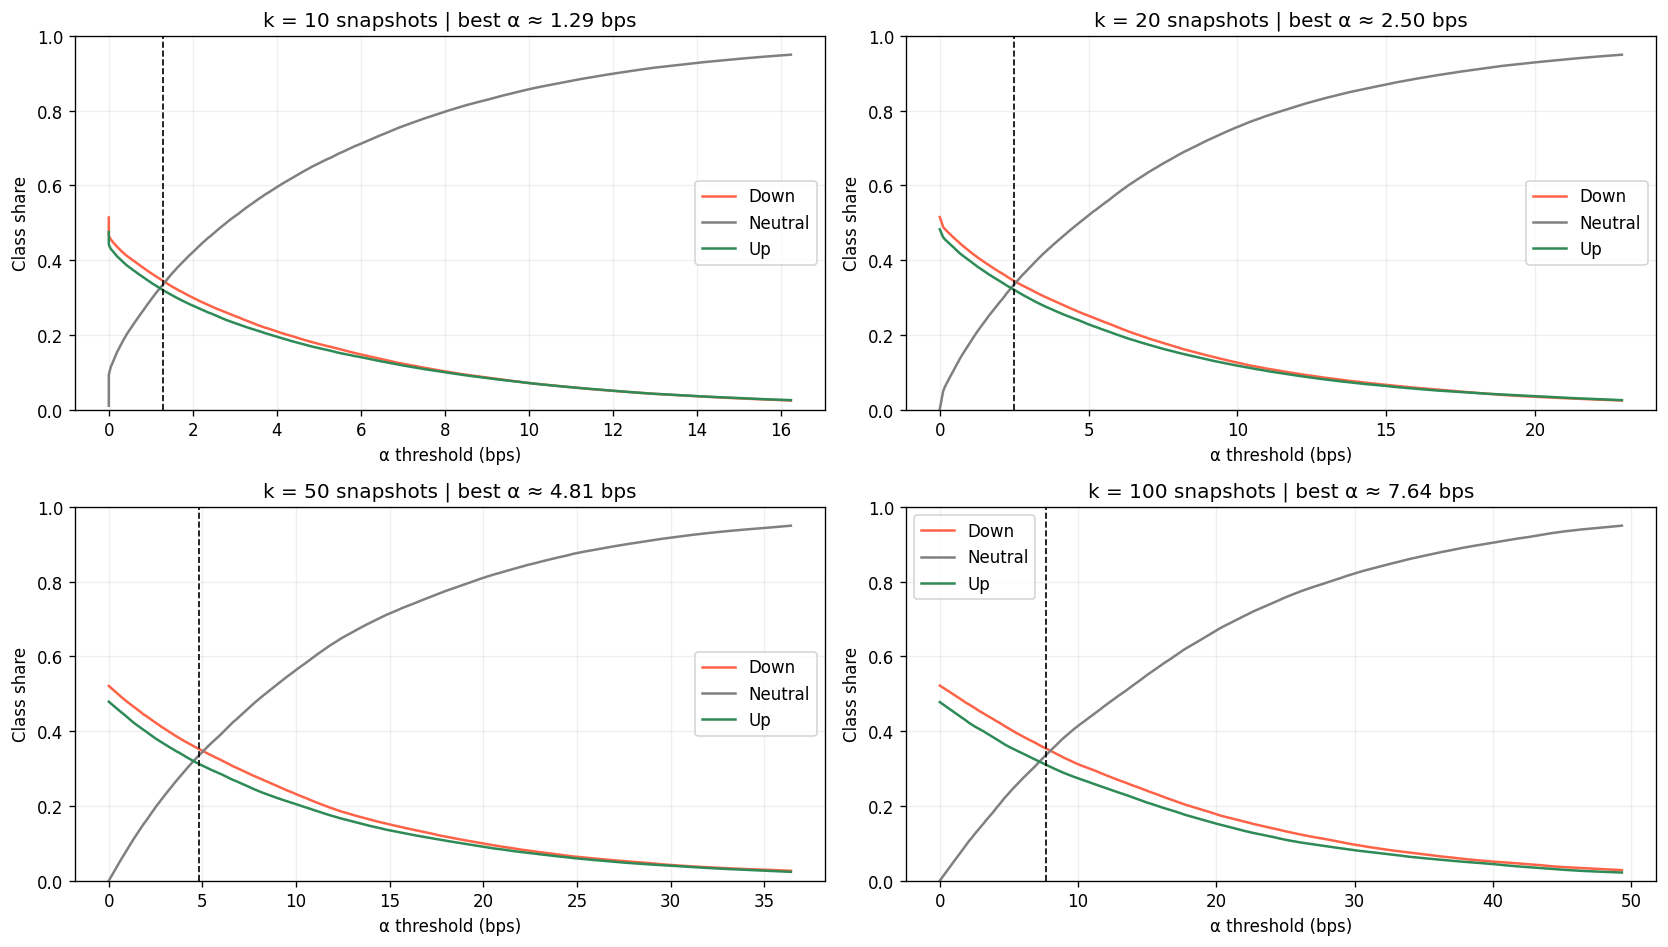

In [56]:
fig, axes = plt.subplots(
    int(np.ceil(len(HORIZONS) / 2)),
    2,
    figsize=(14, 4 * int(np.ceil(len(HORIZONS) / 2))),
    squeeze=False,
)

for ax, horizon in zip(axes.flat, HORIZONS):
    grid = alpha_grids[horizon]
    best = grid.sort_values(["balance_score", "up_down_gap", "alpha"]).iloc[0]

    ax.plot(grid["alpha_bps"], grid["down_share"], color="tomato", label="Down")
    ax.plot(grid["alpha_bps"], grid["neutral_share"], color="grey", label="Neutral")
    ax.plot(grid["alpha_bps"], grid["up_share"], color="seagreen", label="Up")
    ax.axvline(best["alpha_bps"], color="black", linestyle="--", lw=1)

    ax.set_title(f"k = {horizon} snapshots | best α ≈ {best['alpha_bps']:.2f} bps")
    ax.set_xlabel("α threshold (bps)")
    ax.set_ylabel("Class share")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.2)
    ax.legend()

for ax in axes.flat[len(HORIZONS) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
for row in best_alpha_summary.itertuples(index=False):
    horizon = int(row.horizon)
    alpha = float(row.alpha)
    returns, labels = make_deeplob_labels(mid, horizon, alpha)
    ob[f"deeplob_ret_k{horizon}"] = returns
    ob[f"deeplob_label_k{horizon}"] = pd.Series(labels, index=ob.index).astype("Int64")

label_cols = [f"deeplob_label_k{horizon}" for horizon in HORIZONS]
ret_cols = [f"deeplob_ret_k{horizon}" for horizon in HORIZONS]
ob[["time", "mid_price", *ret_cols, *label_cols]].head(10)

,time,mid_price,deeplob_ret_k10,deeplob_ret_k20,deeplob_ret_k50,deeplob_ret_k100,deeplob_label_k10,deeplob_label_k20,deeplob_label_k50,deeplob_label_k100
0,2026-06-08 13:06:14,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
1,2026-06-08 13:06:24,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2,2026-06-08 13:06:34,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
3,2026-06-08 13:06:44,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
4,2026-06-08 13:06:54,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
5,2026-06-08 13:07:04,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
6,2026-06-08 13:07:14,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
7,2026-06-08 13:07:24,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
8,2026-06-08 13:07:34,1.127625e+11,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
9,2026-06-08 13:07:44,1.127625e+11,-0.000048,NaN,NaN,NaN,0,<NA>,<NA>,<NA>
